In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\mldl\task3\Metro_Interstate_Traffic_Volume.csv')
print(df.shape)
print(df.head())
print(df.info())
print(df.isnull().sum())

(48204, 9)
  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 n

In [3]:
df['date_time'] = pd.to_datetime(df['date_time'])
 
df['hour']        = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']       = df['date_time'].dt.month
df['year']        = df['date_time'].dt.year
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
 
df.drop(columns=['date_time'], inplace=True)

In [4]:
X_encoded = pd.get_dummies(df, columns=['holiday', 'weather_main', 'weather_description'])
 
y         = X_encoded['traffic_volume']
X_encoded = X_encoded.drop(columns=['traffic_volume'])
 
print('X shape:', X_encoded.shape)
print('y shape:', y.shape)

X shape: (48204, 69)
y shape: (48204,)


count    48204.000000
mean      3259.818355
std       1986.860670
min          0.000000
25%       1193.000000
50%       3380.000000
75%       4933.000000
max       7280.000000
Name: traffic_volume, dtype: float64


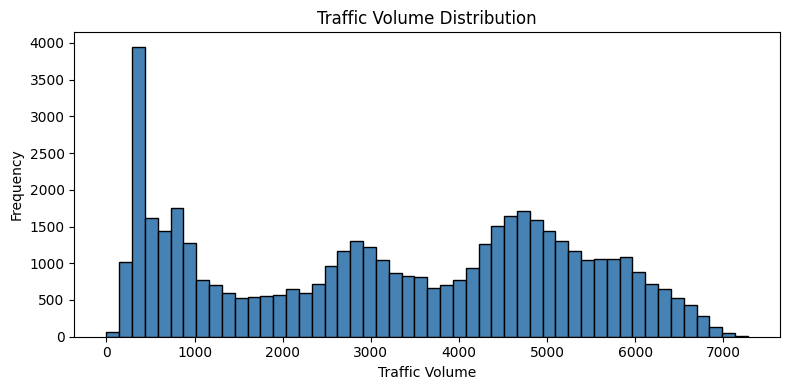

In [5]:
print(y.describe())
 
plt.figure(figsize=(8, 4))
plt.hist(y, bins=50, color='steelblue', edgecolor='black')
plt.title('Traffic Volume Distribution')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, random_state=42, test_size=0.2
)
 
print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)

Train size: (38563, 69)
Test size:  (9641, 69)


In [7]:
clf_xgb = xgb.XGBRegressor(
    objective='reg:squarederror',
    seed=42,
    early_stopping_rounds=10,
    eval_metric='rmse'        # moved here too
)

clf_xgb.fit(
    X_train,
    y_train,
    verbose=True,
    eval_set=[(X_test, y_test)]
)

[0]	validation_0-rmse:1447.26281
[1]	validation_0-rmse:1082.06796
[2]	validation_0-rmse:847.01834
[3]	validation_0-rmse:701.83585
[4]	validation_0-rmse:612.84642
[5]	validation_0-rmse:558.53010
[6]	validation_0-rmse:528.81830
[7]	validation_0-rmse:509.63854
[8]	validation_0-rmse:494.97700
[9]	validation_0-rmse:486.65121
[10]	validation_0-rmse:481.68705
[11]	validation_0-rmse:474.93806
[12]	validation_0-rmse:468.56378
[13]	validation_0-rmse:462.46470
[14]	validation_0-rmse:457.49195
[15]	validation_0-rmse:454.33501
[16]	validation_0-rmse:452.07585
[17]	validation_0-rmse:449.07455
[18]	validation_0-rmse:445.64057
[19]	validation_0-rmse:444.08487
[20]	validation_0-rmse:441.45196
[21]	validation_0-rmse:440.44012
[22]	validation_0-rmse:437.46481
[23]	validation_0-rmse:436.16709
[24]	validation_0-rmse:435.33263
[25]	validation_0-rmse:433.70631
[26]	validation_0-rmse:433.14969
[27]	validation_0-rmse:432.12495
[28]	validation_0-rmse:431.12359
[29]	validation_0-rmse:430.52744
[30]	validation_0-

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method


Preliminary Model — RMSE: 411.46 | R²: 0.9572


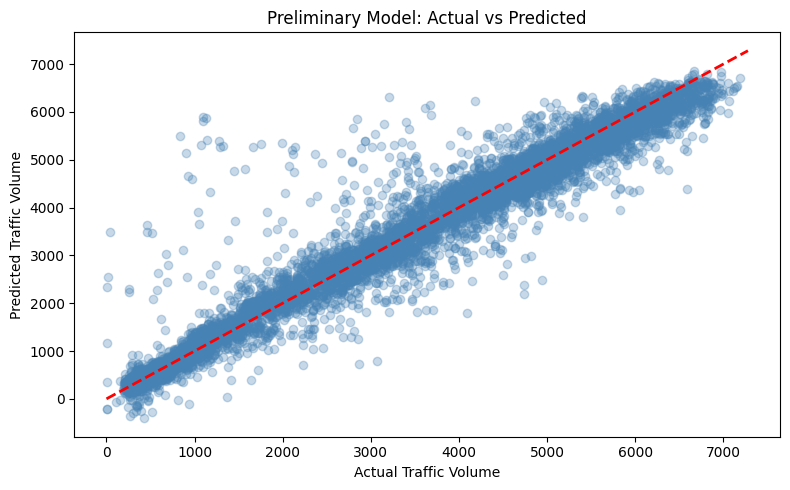

In [8]:
y_pred = clf_xgb.predict(X_test)
 
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f'\nPreliminary Model — RMSE: {rmse:.2f} | R²: {r2:.4f}')
 
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Preliminary Model: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [9]:
param_grid = {
    'max_depth':     [4],
    'learning_rate': [0.1, 0.5, 1],
    'gamma':         [0.25],
    'reg_lambda':    [10.0, 20, 100],
}

In [10]:
optimal_params = GridSearchCV(
    estimator=xgb.XGBRegressor(
        objective='reg:squarederror',
        seed=42,
        subsample=0.9,
        colsample_bytree=0.5
    ),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    verbose=0,
    n_jobs=10,
    cv=3
)

optimal_params.fit(X_train, y_train)

print('Best params:', optimal_params.best_params_)

Best params: {'gamma': 0.25, 'learning_rate': 0.5, 'max_depth': 4, 'reg_lambda': 20}


In [11]:
clf_xgb = xgb.XGBRegressor(
    seed=42,
    objective='reg:squarederror',
    gamma=0.25,
    learning_rate=0.1,
    max_depth=4,
    reg_lambda=10,
    subsample=0.9,
    colsample_bytree=0.5,
    early_stopping_rounds=10,
    eval_metric='rmse'
)

clf_xgb.fit(
    X_train,
    y_train,
    verbose=True,
    eval_set=[(X_test, y_test)]
)

[0]	validation_0-rmse:1814.04991
[1]	validation_0-rmse:1658.85724
[2]	validation_0-rmse:1521.12960
[3]	validation_0-rmse:1506.65988
[4]	validation_0-rmse:1400.30328
[5]	validation_0-rmse:1291.61658
[6]	validation_0-rmse:1195.18885
[7]	validation_0-rmse:1190.01237
[8]	validation_0-rmse:1106.74152
[9]	validation_0-rmse:1102.01167
[10]	validation_0-rmse:1096.52580
[11]	validation_0-rmse:1024.12448
[12]	validation_0-rmse:1019.11683
[13]	validation_0-rmse:963.64750
[14]	validation_0-rmse:907.79631
[15]	validation_0-rmse:856.64127
[16]	validation_0-rmse:814.69888
[17]	validation_0-rmse:811.69202
[18]	validation_0-rmse:773.53197
[19]	validation_0-rmse:740.70418
[20]	validation_0-rmse:713.03428
[21]	validation_0-rmse:710.11788
[22]	validation_0-rmse:706.75805
[23]	validation_0-rmse:686.57214
[24]	validation_0-rmse:665.74063
[25]	validation_0-rmse:651.31957
[26]	validation_0-rmse:649.79965
[27]	validation_0-rmse:634.53131
[28]	validation_0-rmse:633.36720
[29]	validation_0-rmse:631.05238
[30]	va

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.5
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",10
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=


Optimized Model — RMSE: 484.96 | R²: 0.9405
RMSE improvement: -73.50


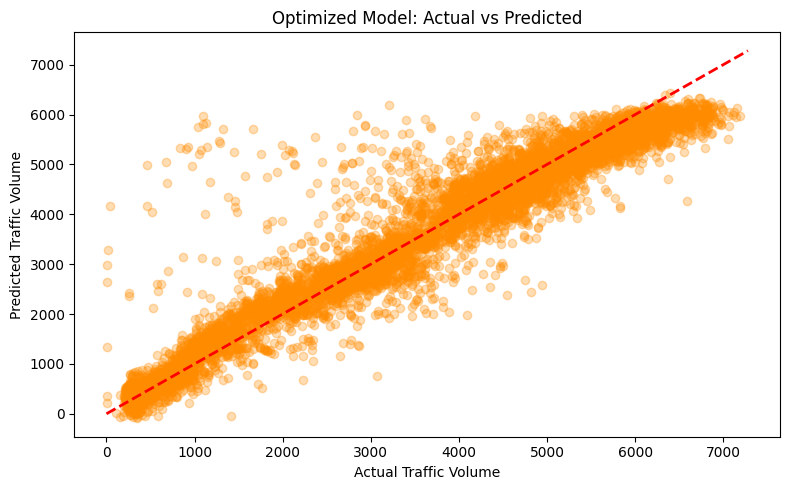

In [12]:
y_pred_opt = clf_xgb.predict(X_test)
 
rmse_opt = np.sqrt(mean_squared_error(y_test, y_pred_opt))
r2_opt   = r2_score(y_test, y_pred_opt)
print(f'\nOptimized Model — RMSE: {rmse_opt:.2f} | R²: {r2_opt:.4f}')
print(f'RMSE improvement: {rmse - rmse_opt:.2f}')
 
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_opt, alpha=0.3, color='darkorange')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual Traffic Volume')
plt.ylabel('Predicted Traffic Volume')
plt.title('Optimized Model: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [13]:
clf_xgb_tree = xgb.XGBRegressor(
    seed=42,
    objective='reg:squarederror',
    gamma=0.25,
    learning_rate=0.1,
    max_depth=4,
    reg_lambda=10,
    subsample=0.9,
    colsample_bytree=0.5,
    n_estimators=1   ## set to 1 so we can get gain, cover etc.
)
clf_xgb_tree.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.5
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [14]:
bst = clf_xgb_tree.get_booster()
for importance_type in ('weight', 'gain', 'cover', 'total_gain', 'total_cover'):
    print('%s: ' % importance_type, bst.get_score(importance_type=importance_type))
 
node_params = {
    'shape': 'box',
    'style': 'filled, rounded',
    'fillcolor': '#78cbe'
}
leaf_params = {
    'shape': 'box',
    'style': 'filled',
    'fillcolor': '#e48038'
}

weight:  {'temp': 1.0, 'hour': 10.0, 'is_weekend': 3.0}
gain:  {'temp': 10745248.0, 'hour': 10767529984.0, 'is_weekend': 4285717504.0}
cover:  {'temp': 1066.0, 'hour': 11553.7001953125, 'is_weekend': 7200.33349609375}
total_gain:  {'temp': 10745248.0, 'hour': 107675303936.0, 'is_weekend': 12857152512.0}
total_cover:  {'temp': 1066.0, 'hour': 115537.0, 'is_weekend': 21601.0}


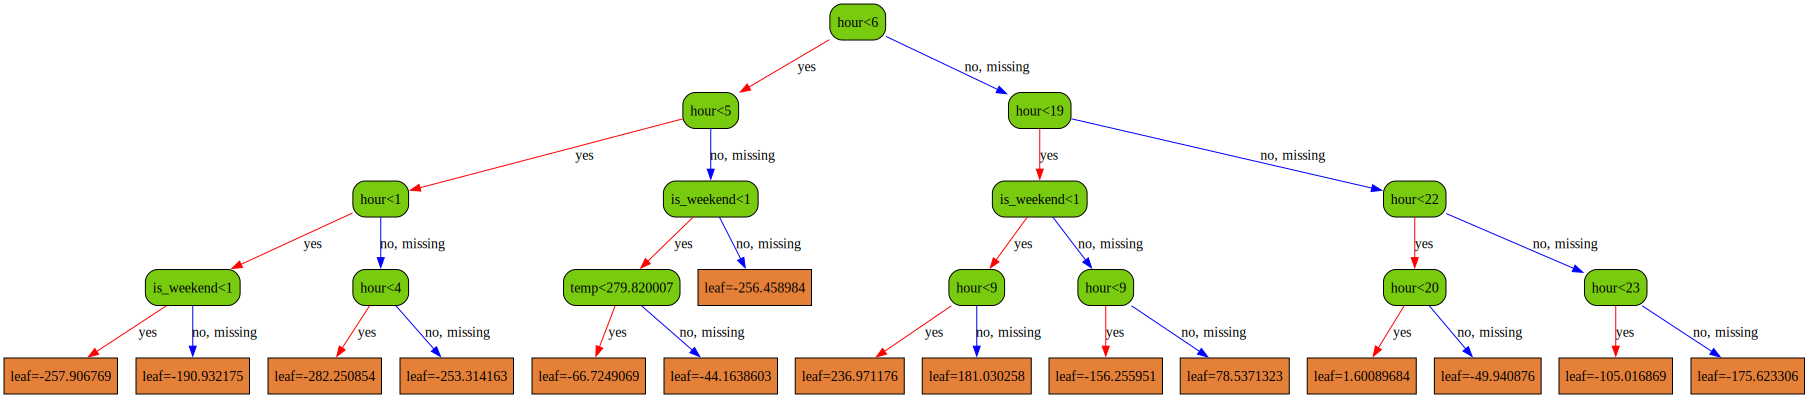

In [15]:
xgb.to_graphviz(
    clf_xgb_tree,
    num_trees=0,
    size='10,10',
    condition_node_params=node_params,
    leaf_node_params=leaf_params
)

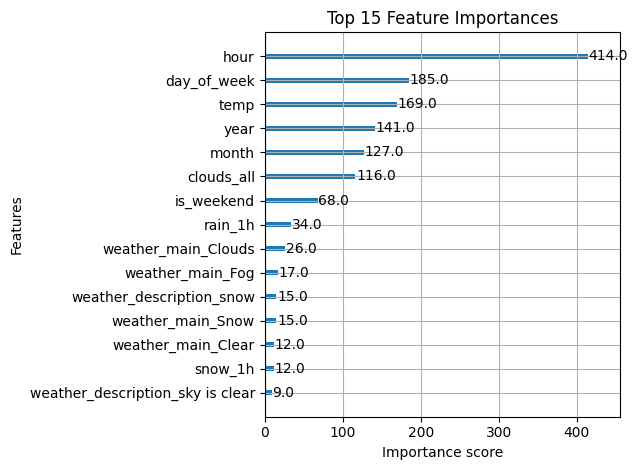

In [16]:
xgb.plot_importance(clf_xgb, max_num_features=15)
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()